In [ ]:
# Package installation and loading

# Install CoolProp
!pip install CoolProp

# Import necessary packages
import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI
# Add more pakcages as needed


Mass m = 11.22334455667789 kg


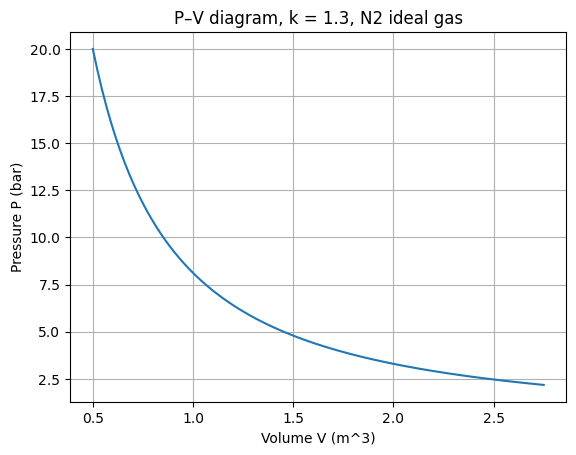

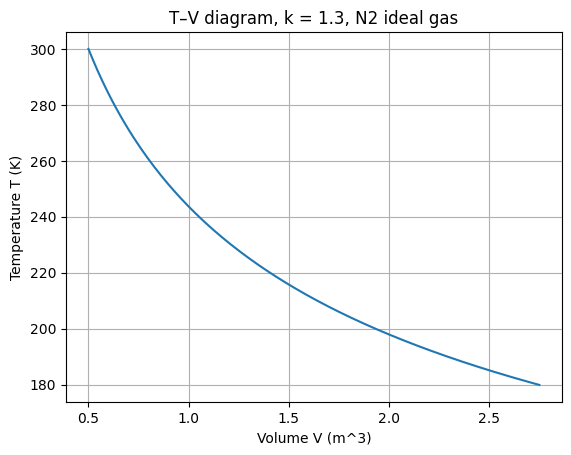

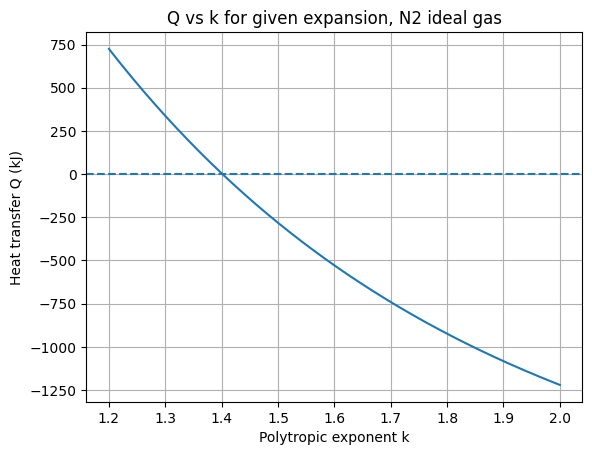

In [10]:
# Q1

# Given data
P1_bar = 20.0
P1 = P1_bar * 100.0        # kPa
V1 = 0.5                   # m^3
V2 = 2.75                  # m^3
T1 = 300.0                 # K
R = 0.297                  # kJ/(kgK)
Cv = 0.740                 # kJ/(kgK)

# Mass of nitrogen
m = P1 * V1 / (R * T1)     # kg
print("Mass m =", m, "kg")

# P–V and T–V for k = 1.3
k = 1.3

V = np.linspace(V1, V2, 200)
P = P1 * (V1 / V)**k               # kPa
T = P * V / (m * R)                # K

# P–V plot
plt.figure()
plt.plot(V, P / 100.0)             # convert to bar for nicer axis
plt.xlabel("Volume V (m^3)")
plt.ylabel("Pressure P (bar)")
plt.title(f"P–V diagram, k = {k}, N2 ideal gas")
plt.grid(True)

# T–V plot
plt.figure()
plt.plot(V, T)
plt.xlabel("Volume V (m^3)")
plt.ylabel("Temperature T (K)")
plt.title(f"T–V diagram, k = {k}, N2 ideal gas")
plt.grid(True)

plt.show()

# Q vs k from 1.2 to 2.0
def heat_transfer_Q(k):
    # end pressure
    P2 = P1 * (V1 / V2)**k          # kPa
    # work (kJ)
    W = (P2 * V2 - P1 * V1) / (1.0 - k)
    # end temperature
    T2 = T1 * (V1 / V2)**(k - 1.0)
    # change in internal energy (kJ)
    dU = m * Cv * (T2 - T1)
    # heat transfer (kJ)
    Q = dU + W
    return Q

k_vals = np.linspace(1.2, 2.0, 200)
Q_vals = np.array([heat_transfer_Q(k) for k in k_vals])

plt.figure()
plt.plot(k_vals, Q_vals)
plt.xlabel("Polytropic exponent k")
plt.ylabel("Heat transfer Q (kJ)")
plt.title("Q vs k for given expansion, N2 ideal gas")
plt.axhline(0, linestyle="--")     # show where Q changes sign
plt.grid(True)
plt.show()


h1 = 3446.02 kJ/kg,  s1 = 7.092 kJ/(kg·K)


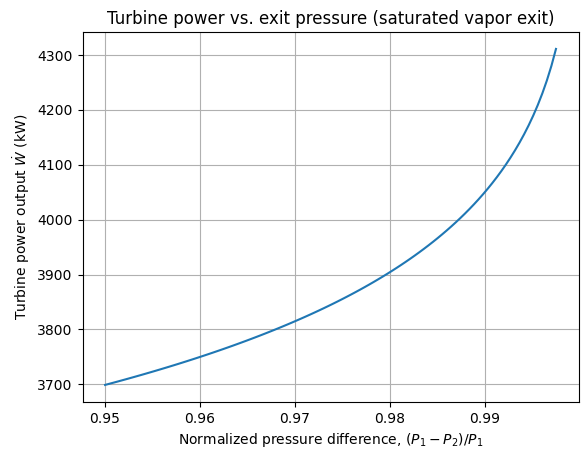

Ideal turbine (s1 = s2, saturated vapor exit) -> P2 = 2.219 bar


In [13]:
# Q2

import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# Given inlet state
P1_bar = 40.0
P1 = P1_bar * 1e5          # Pa
T1 = 500.0 + 273.15        # K
mdot = 5.0                 # kg/s

# Inlet properties
h1 = PropsSI('H', 'T', T1, 'P', P1, 'Water')      # J/kg
s1 = PropsSI('S', 'T', T1, 'P', P1, 'Water')      # J/(kgK)

print(f"h1 = {h1/1000:.2f} kJ/kg,  s1 = {s1/1000:.3f} kJ/(kg·K)")

# power vs exit pressure

P2_bar_array = np.linspace(0.1, 2.0, 100)   # bar
power_array = []

for P2_bar in P2_bar_array:
    P2 = P2_bar * 1e5                       # Pa
    # saturated vapor at P2
    h2 = PropsSI('H', 'P', P2, 'Q', 1.0, 'Water')   # J/kg
    Wdot = mdot * (h1 - h2) / 1000.0        # kW
    power_array.append(Wdot)

power_array = np.array(power_array)

# normalized pressure difference (P1 - P2)/P1
x_norm = (P1_bar - P2_bar_array) / P1_bar

plt.figure()
plt.plot(x_norm, power_array)
plt.xlabel(r"Normalized pressure difference, $(P_1 - P_2)/P_1$")
plt.ylabel(r"Turbine power output $\dot{W}$ (kW)")
plt.title("Turbine power vs. exit pressure (saturated vapor exit)")
plt.grid(True)
plt.show()

# ideal turbine exit pressure

# Search in 0.1–2 bar for saturated vapor with s_g = s1
P2_bar_search = np.linspace(0.5, 3.0, 5000)  # wider + finer grid
s_diff = []
for P2_bar in P2_bar_search:
    P2 = P2_bar * 1e5
    s_g = PropsSI('S', 'P', P2, 'Q', 1.0, 'Water')
    s_diff.append(abs(s_g - s1))

P2_ideal_bar = P2_bar_search[np.argmin(s_diff)]

print(f"Ideal turbine (s1 = s2, saturated vapor exit) -> P2 = {P2_ideal_bar:.3f} bar")
